# Caso de Estudio — Minería de Datos: Zoomies.cr
## Tienda de mascotas en Costa Rica | Web Mining + Reglas de Asociación + Redes Neuronales

**URL del escenario**: `https://zoomies.cr/`

| Módulo | Técnica | Referencia |
|--------|---------|------------|
| **Web Mining — Técnica 1** | `urllib` + `BeautifulSoup` + CSS selectors | WebMining.ipynb |
| **Web Mining — Técnica 2** | `requests` + API interna + `re.findall()` | WebMining3.ipynb |
| **Web Mining — Técnica 3** | `Selenium` + XPath (sitio JavaScript) | WebMining2.ipynb |
| **Reglas de Asociación** | `TransactionEncoder` + `apriori` + `association_rules` | ReglasAsociacion.ipynb |
| **Redes Neuronales** | 3 arquitecturas `MLPClassifier`: relu+adam, tanh+adam, tanh+lbfgs | DeepLearning2.ipynb |

## 0. Importaciones y Configuración

In [62]:
import sys, warnings, os, re, json, time, random
warnings.filterwarnings('ignore')

from urllib.request import Request, urlopen
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import paquete_mineria2 as pm
from sklearn.model_selection import train_test_split

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías listas.')
print(f'MLXTEND  : {pm.MLXTEND_AVAILABLE}')
print(f'MLP      : {pm.MLP_SKLEARN_AVAILABLE}')
print(f'Keras/TF : {pm.KERAS_NN_AVAILABLE}')
print(f'Selenium : {pm.SELENIUM_AVAILABLE}')

URL = 'https://zoomies.cr/'
print(f'\nSitio objetivo: {URL}')

Librerías listas.
MLXTEND  : True
MLP      : True
Keras/TF : True
Selenium : True

Sitio objetivo: https://zoomies.cr/


---
## 1. Web Mining — Zoomies.cr

### ¿Cómo está construido el sitio?

Usando **Wappalyzer**, identificamos lo siguiente en Zoomies.cr:

| Tecnología | Rol en el sitio | Impacto en el scraping |
|-----------|-----------------|------------------------|
| **React + React Router** | Framework frontend — SPA | El HTML inicial llega vacío. El catálogo lo construye JavaScript en el navegador del usuario, no el servidor |
| **Node.js + Express** | Servidor backend | Expone rutas de API (ej. `/api/config/public`) que podemos consultar directamente con `requests` |
| **Algolia** | Motor de búsqueda de productos | Tiene una API con el catálogo completo, accesible con credenciales públicas del sitio |
| **Cloudflare** | CDN + seguridad | Puede bloquear scrapers sin `User-Agent` o con demasiadas peticiones seguidas |
| **Firebase** | Base de datos en la nube | Parte del backend de almacenamiento |
| **Imagekit** | CDN de imágenes | Los `src` de fotos de productos apuntan a este dominio externo, no a zoomies.cr |

### Técnicas de Web Mining

| Técnica | Herramientas | Cuándo se usa |
|---------|-------------|---------------|
| **T1 — urllib + BeautifulSoup** | `urllib`, `BeautifulSoup`, CSS selectors | Sitios estáticos (WordPress, portales de noticias). En Zoomies.cr el HTML llega vacío por ser SPA React — no hay catálogo que extraer. |
| **T2 — requests + API + regex** | `requests`, JSON, `re` | Sitios modernos con API interna. Zoomies expone credenciales de Algolia en `/api/config/public`, lo que permite descargar el catálogo completo. **Esta es la técnica aplicada.** |
| **T3 — Selenium + XPath** | `selenium`, `geckodriver`, XPath | Cualquier sitio con JavaScript cuando no existe API. Controla un navegador real para ver el sitio ya renderizado. |

A continuación se aplica la **Técnica 2** para extraer el catálogo completo de Zoomies.cr.

### Aplicación — Técnica 2: `requests` + API interna + `re`
Zoomies.cr usa **Algolia** como motor de búsqueda y expone sus credenciales de solo lectura en `/api/config/public`. Con `requests` consultamos la Browse API para obtener el catálogo completo, luego aplicamos `re.findall()` y `re.sub()` sobre los textos extraídos.

In [63]:
wm = pm.WebMining()

# Paso 1: Obtener credenciales de la API con requests.get()
cfg_url = URL + 'api/config/public'
cfg     = requests.get(cfg_url, headers={'User-Agent': 'Mozilla/5.0'}).json()

app_id  = cfg['algoliaAppId']
api_key = cfg['algoliaApiKey']

print(f'App ID         : {app_id}')
print(f'Clave API      : {api_key[:8]}...')
print(f'Índice catalog : PRD_Zoomies_Catalog')

WebScraping inicializado
WebMining inicializado
App ID         : LN5ZRCOHR0
Clave API      : c49e9426...
Índice catalog : PRD_Zoomies_Catalog


In [64]:
# Paso 2: Descargar catálogo completo con paginación por cursor
headers_alg = {
    'X-Algolia-Application-Id': app_id,
    'X-Algolia-API-Key'       : api_key,
    'Content-Type'            : 'application/json',
}

hits, cursor = [], None
while True:
    body = {'query': '', 'hitsPerPage': 1000}
    if cursor:
        body['cursor'] = cursor
    resp   = requests.post(
        f'https://{app_id}.algolia.net/1/indexes/PRD_Zoomies_Catalog/browse',
        headers=headers_alg, json=body, timeout=20
    )
    data   = resp.json()
    hits.extend(data.get('hits', []))
    cursor = data.get('cursor')
    print(f'  Acumulado: {len(hits)} productos')
    if not cursor:
        break

print(f'\nTotal registros: {len(hits)}')

  Acumulado: 1000 productos
  Acumulado: 1137 productos

Total registros: 1137


In [65]:
# Paso 3: Construir DataFrame
filas = []
for p in hits:
    sd = (p.get('storeDetail') or {}).get('501') or {}
    filas.append({
        'Nombre'       : p.get('zooDescripcionZoomies', ''),
        'Marca'        : p.get('marca', ''),
        'Mascota'      : p.get('zoomiesParent3', ''),
        'Tipo'         : p.get('zoomiesParent2', ''),
        'Subcategoria' : p.get('zoomiesParent', ''),
        'Edad'         : p.get('zooEdad', ''),
        'Tamano'       : p.get('ecoTamano', ''),
        'Precio'       : sd.get('amount') or sd.get('basePrice'),
        'Descuento_pct': sd.get('percentDiscount', 0) or 0,
        'Disponible'   : sd.get('productAvailable', False),
        'VentasMes'    : p.get('lastMonthSales', 0) or 0,
    })

df_raw = pd.DataFrame(filas)
print(f'DataFrame: {df_raw.shape}')
df_raw.head(3)

DataFrame: (1137, 11)


,Nombre,Marca,Mascota,Tipo,Subcategoria,Edad,Tamano,Precio,Descuento_pct,Disponible,VentasMes
0,Alimento Húmedo Gato Paté Salmón Felix Lata 1...,FELIX,GATOS,ALIMENTOS,HUMEDOS,ADULTO,GRANDE,1170.0,0,True,5509425
1,ARENA GATO EXTREME LIBRE DE POLVO FEBREZE FRES...,FRESH STEP,GATOS,HIGIENE,ARENEROS Y ARENAS,ADULTO,GRANDE,9475.0,0,True,3455655
2,Alimento Húmedo Gato Paté Pavo Felix Lata 156 G,FELIX,GATOS,ALIMENTOS,HUMEDOS,ADULTO,GRANDE,1170.0,0,True,2899405


In [66]:
# Paso 4: Aplicar re.findall() sobre los nombres de producto
# (igual que en WebMining3.ipynb: extraer datos de texto con regex)

# re.findall → extraer peso / gramaje
PATRON_PESO = r'(\d+(?:[.,]\d+)?)\s*(g|kg|lb|lbs|oz|ml|L|cc|lt)\b'
PATRON_PRES = r'\b(lata|bolsa|caja|sobre|frasco|tarro|tubo|paquete)\b'

def extraer_peso(nombre):
    m = re.search(PATRON_PESO, nombre, re.IGNORECASE)
    return (float(m.group(1).replace(',','.')), m.group(2).lower()) if m else (None, None)

df_raw[['Peso_num', 'Peso_unidad']] = df_raw['Nombre'].apply(
    lambda n: pd.Series(extraer_peso(n))
)
df_raw['Presentacion'] = df_raw['Nombre'].apply(
    lambda n: (re.findall(PATRON_PRES, n, re.IGNORECASE) or [None])[0]
)

# re.sub → limpiar espacios dobles en nombres
df_raw['Nombre'] = df_raw['Nombre'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print(f'Productos con peso extraído via regex: {df_raw["Peso_num"].notna().sum()}')
print(f'\nUnidades encontradas (re.findall):')
print(df_raw['Peso_unidad'].value_counts().head(8).to_string())
print(f'\nTipos de presentación (re.findall):')
print(df_raw['Presentacion'].value_counts().head(6).to_string())

Productos con peso extraído via regex: 86

Unidades encontradas (re.findall):
Peso_unidad
kg     46
ml     24
g      10
oz      3
lbs     2
l       1

Tipos de presentación (re.findall):
Presentacion
Bolsa    16
Lata      4
BOLSA     2
bolsa     1
Sobre     1


In [67]:
# Paso 5: Limpieza y creación de variables derivadas
df = df_raw[
    df_raw['Mascota'].isin(['PERROS', 'GATOS']) &
    df_raw['Precio'].notna() &
    (df_raw['Precio'] > 0)
].copy().reset_index(drop=True)

for col in ['Mascota', 'Tipo', 'Subcategoria', 'Edad', 'Tamano']:
    df[col] = df[col].replace('', 'OTRO')

df['RangoPrecio'] = df['Precio'].apply(
    lambda p: 'BAJO' if p < 5_000 else ('MEDIO' if p < 25_000 else 'ALTO')
)

wm.resumen_datos(df)
df.head(3)


RESUMEN DE DATOS EXTRAÍDOS
Filas: 1103 | Columnas: 15
Columnas: ['Nombre', 'Marca', 'Mascota', 'Tipo', 'Subcategoria', 'Edad', 'Tamano', 'Precio', 'Descuento_pct', 'Disponible', 'VentasMes', 'Peso_num', 'Peso_unidad', 'Presentacion', 'RangoPrecio']

Nulos:
Nombre             0
Marca              0
Mascota            0
Tipo               0
Subcategoria       0
                ... 
VentasMes          0
Peso_num        1020
Peso_unidad     1020
Presentacion    1084
RangoPrecio        0
Length: 15, dtype: int64

Muestra:
                                              Nombre       Marca Mascota  \
0  Alimento Húmedo Gato Paté Salmón Felix Lata 156 G       FELIX   GATOS   
1  ARENA GATO EXTREME LIBRE DE POLVO FEBREZE FRES...  FRESH STEP   GATOS   
2    Alimento Húmedo Gato Paté Pavo Felix Lata 156 G       FELIX   GATOS   
3          ALIMENTO GATO SECO ADULTO PURINA CAT CHOW    CAT CHOW   GATOS   
4  ALIMENTO GATO HUMEDO ADULTO SALMON ESTERILIZAD...         ONE   GATOS   

        Tipo       

,Nombre,Marca,Mascota,Tipo,Subcategoria,Edad,Tamano,Precio,Descuento_pct,Disponible,VentasMes,Peso_num,Peso_unidad,Presentacion,RangoPrecio
0,Alimento Húmedo Gato Paté Salmón Felix Lata 156 G,FELIX,GATOS,ALIMENTOS,HUMEDOS,ADULTO,GRANDE,1170.0,0,True,5509425,156.0,g,Lata,BAJO
1,ARENA GATO EXTREME LIBRE DE POLVO FEBREZE FRES...,FRESH STEP,GATOS,HIGIENE,ARENEROS Y ARENAS,ADULTO,GRANDE,9475.0,0,True,3455655,NaN,None,None,MEDIO
2,Alimento Húmedo Gato Paté Pavo Felix Lata 156 G,FELIX,GATOS,ALIMENTOS,HUMEDOS,ADULTO,GRANDE,1170.0,0,True,2899405,156.0,g,Lata,BAJO


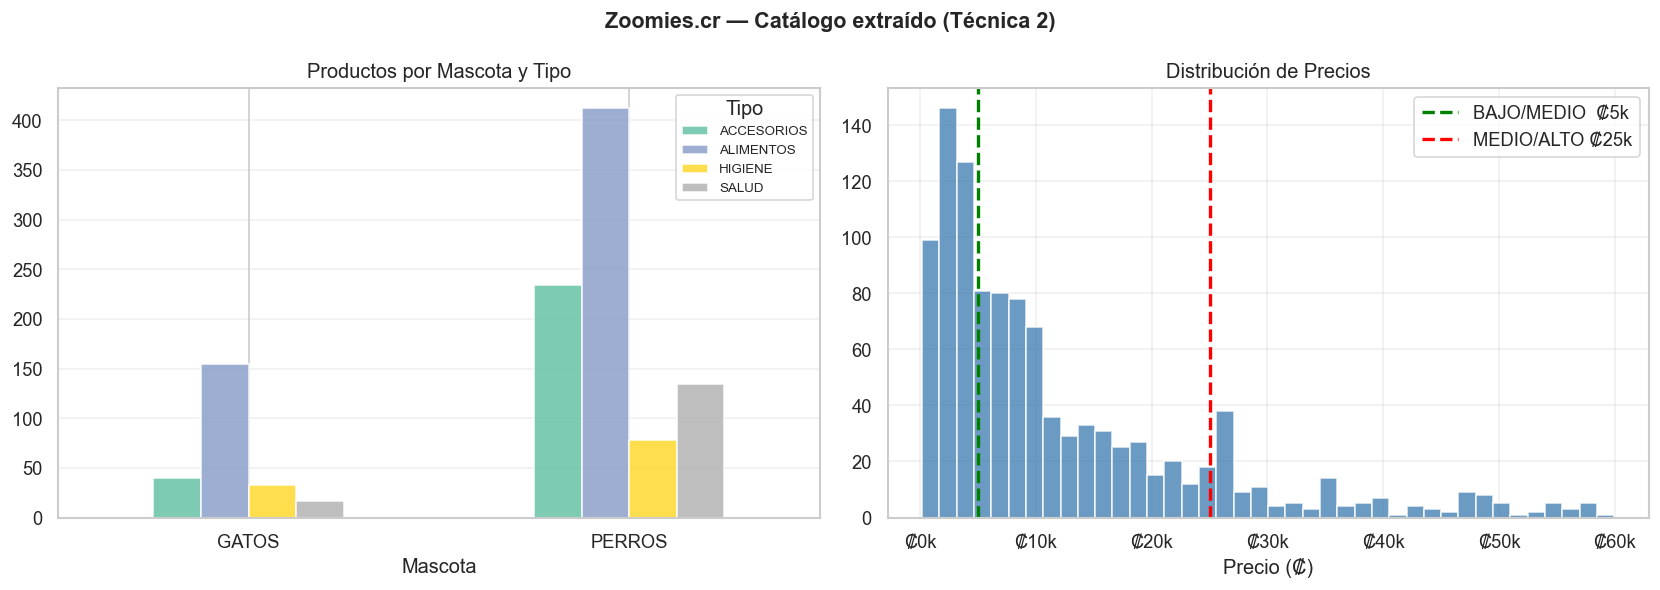

In [68]:
# Análisis exploratorio del catálogo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Productos por mascota y tipo
pivot = df.groupby(['Mascota','Tipo']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', alpha=0.85)
axes[0].set_title('Productos por Mascota y Tipo')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Tipo', fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Distribución de precios
precio_cap = df[df['Precio'] <= 60_000]['Precio']
axes[1].hist(precio_cap, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(5_000,  color='green', linestyle='--', lw=2, label='BAJO/MEDIO  ₡5k')
axes[1].axvline(25_000, color='red',   linestyle='--', lw=2, label='MEDIO/ALTO ₡25k')
axes[1].set_title('Distribución de Precios')
axes[1].set_xlabel('Precio (₡)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₡{x/1000:.0f}k'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Zoomies.cr — Catálogo extraído (Técnica 2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

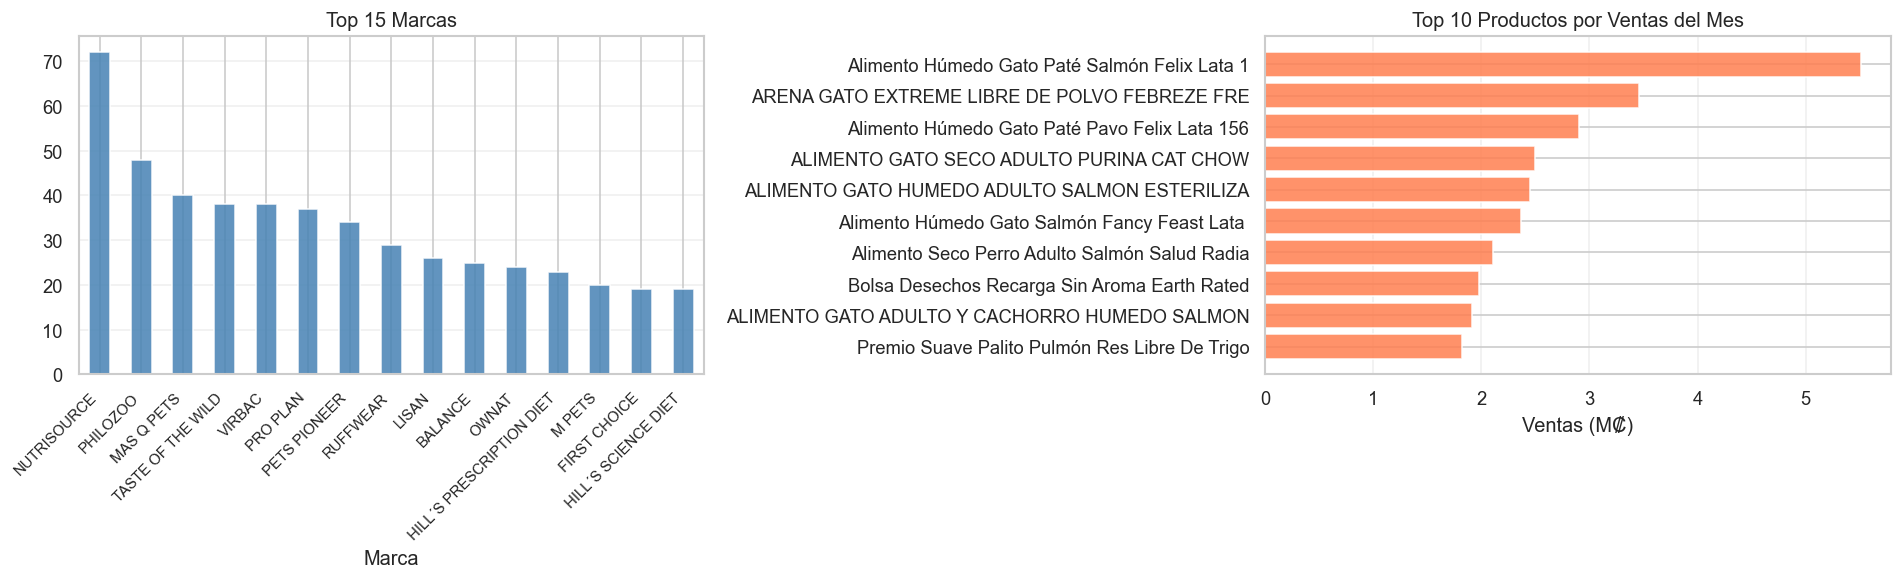

Exportado: ../data/zoomies_catalogo.csv (1103 filas × 15 columnas)


'../data/zoomies_catalogo.csv'

In [69]:
# Top marcas y top ventas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['Marca'].value_counts().head(15).plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 15 Marcas')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

top10 = df.nlargest(10, 'VentasMes').copy()
top10['Nombre_corto'] = top10['Nombre'].str[:45]
axes[1].barh(top10['Nombre_corto'], top10['VentasMes'] / 1_000_000, color='coral', alpha=0.85)
axes[1].set_title('Top 10 Productos por Ventas del Mes')
axes[1].set_xlabel('Ventas (M₡)')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Guardar CSV
os.makedirs('../data', exist_ok=True)
wm.exportar_csv(df, '../data/zoomies_catalogo.csv')

---
## 2. Reglas de Asociación — Canastas de Compra

Con el catálogo extraído en la Técnica 2 simulamos órdenes de compra. La probabilidad de que una subcategoría aparezca en una canasta es proporcional a las ventas reales del mes (`VentasMes`), lo que hace la simulación coherente con el comportamiento real de los clientes.

- Cada **transacción** = una orden de compra simulada
- Cada **ítem** = subcategoría de producto

In [70]:
random.seed(42)
np.random.seed(42)

df_ventas = df[df['VentasMes'] > 0].copy()
pesos     = df_ventas['VentasMes'].values / df_ventas['VentasMes'].sum()

N_ORDENES = 1_500
filas_trans = []
for id_orden in range(N_ORDENES):
    n_items  = random.randint(2, 6)
    indices  = np.random.choice(len(df_ventas), size=min(n_items*2, len(df_ventas)),
                                replace=False, p=pesos)
    cats_sel = df_ventas.iloc[indices]['Subcategoria'].tolist()
    cats_sel = list(dict.fromkeys(c for c in cats_sel if c and c != 'OTRO'))[:n_items]
    for cat in cats_sel:
        filas_trans.append({'id_compra': id_orden, 'item': cat})

df_trans = pd.DataFrame(filas_trans)
print(f'Transacciones: {df_trans["id_compra"].nunique()}')
print(f'Ítems únicos : {df_trans["item"].nunique()}')
print(f'Total filas  : {len(df_trans)}')

Transacciones: 1500
Ítems únicos : 27
Total filas  : 5726


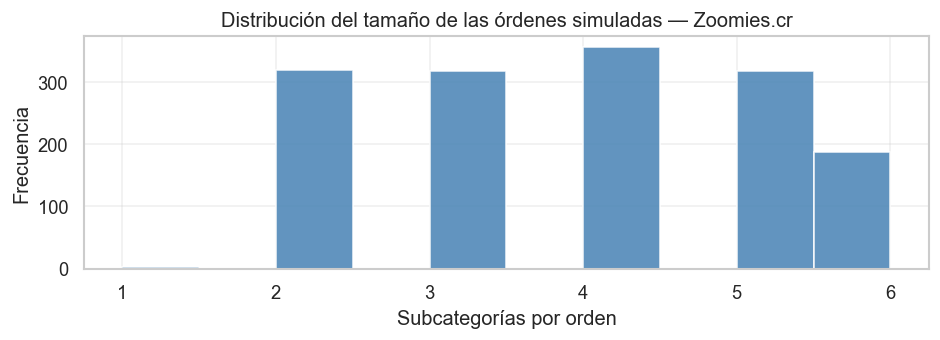


Top 10 subcategorías más frecuentes:
item
HUMEDOS              1190
SECOS                1165
SNACKS Y PREMIOS      903
ARENEROS Y ARENAS     455
JUGUETES              287
BOLSAS                270
SUPLEMENTOS           254
BAÑO Y ASEO           217
PADS                  131
HOGAR                 131


In [71]:
# Distribución del tamaño de las órdenes (igual que en el ejemplo)
fig, ax = plt.subplots(figsize=(8, 3))
df_trans.groupby('id_compra')['item'].size().plot.hist(
    ax=ax, bins=10, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_title('Distribución del tamaño de las órdenes simuladas — Zoomies.cr')
ax.set_xlabel('Subcategorías por orden')
ax.set_ylabel('Frecuencia')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 10 subcategorías más frecuentes:')
print(df_trans['item'].value_counts().head(10).to_string())

Datos cargados: 1500 transacciones, 27 ítems únicos
Matriz codificada: 1500 transacciones × 27 ítems


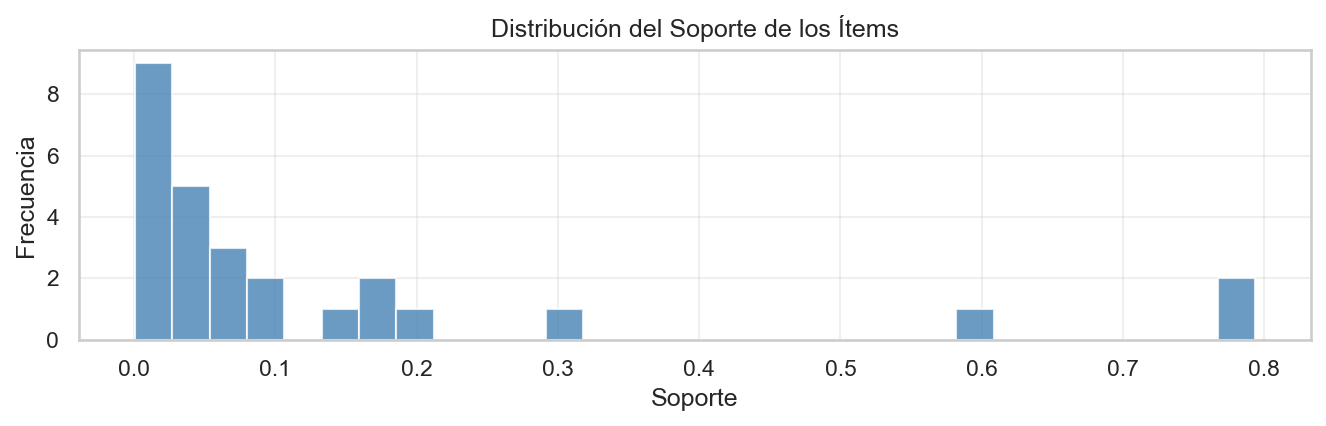

In [72]:
# TransactionEncoder + Apriori (misma lógica que ReglasAsociacion.ipynb)
ra = pm.ReglasAsociacion(df=df_trans, col_id='id_compra', col_item='item')
ra.encodificar()
ra.grafico_soporte(figsize=(9, 3), show=True);

In [73]:
# Itemsets frecuentes
soporte_min = 30 / df_trans['id_compra'].nunique()
print(f'Soporte mínimo: {soporte_min:.4f}  (30 transacciones)')
ra.itemsets_frecuentes(min_support=soporte_min)

print('\nTop 10 itemsets por soporte:')
print(ra.top_itemsets(n=10).to_string(index=False))
print('\nTop 10 itemsets con 2+ ítems:')
print(ra.top_itemsets(n=10, n_items_min=2).to_string(index=False))

Soporte mínimo: 0.0200  (30 transacciones)
Apriori — soporte mínimo: 0.0200...
Itemsets encontrados: 168

Top 10 itemsets por soporte:
 support                           itemsets  n_items
0.793333                          (HUMEDOS)        1
0.776667                            (SECOS)        1
0.629333                   (SECOS, HUMEDOS)        2
0.602000                 (SNACKS Y PREMIOS)        1
0.487333        (SNACKS Y PREMIOS, HUMEDOS)        2
0.476000          (SECOS, SNACKS Y PREMIOS)        2
0.398000 (SECOS, SNACKS Y PREMIOS, HUMEDOS)        3
0.303333                (ARENEROS Y ARENAS)        1
0.242000       (ARENEROS Y ARENAS, HUMEDOS)        2
0.237333         (ARENEROS Y ARENAS, SECOS)        2

Top 10 itemsets con 2+ ítems:
 support                                       itemsets  n_items
0.629333                               (SECOS, HUMEDOS)        2
0.487333                    (SNACKS Y PREMIOS, HUMEDOS)        2
0.476000                      (SECOS, SNACKS Y PREMIOS) 

Reglas generadas: 294
  Confianza: [0.500, 0.947]
  Lift:      [0.852, 1.282]
Reglas con consecuente 'SNACKS Y PREMIOS':
                                   antecedents        consequents  support  confidence     lift
     (ARENEROS Y ARENAS, HUMEDOS, BAÑO Y ASEO) (SNACKS Y PREMIOS) 0.022000    0.750000 1.245847
       (ARENEROS Y ARENAS, SECOS, BAÑO Y ASEO) (SNACKS Y PREMIOS) 0.022000    0.717391 1.191680
(SECOS, COLLARES, CORREAS Y PECHERAS, HUMEDOS) (SNACKS Y PREMIOS) 0.023333    0.714286 1.186521
     (SUPLEMENTOS, ARENEROS Y ARENAS, HUMEDOS) (SNACKS Y PREMIOS) 0.028000    0.711864 1.182499
              (SUPLEMENTOS, ARENEROS Y ARENAS) (SNACKS Y PREMIOS) 0.032000    0.705882 1.172562
              (SECOS, OTROS CUIDADOS, HUMEDOS) (SNACKS Y PREMIOS) 0.024000    0.705882 1.172562
              (ARENEROS Y ARENAS, BAÑO Y ASEO) (SNACKS Y PREMIOS) 0.027333    0.694915 1.154344
          (ARENEROS Y ARENAS, BOLSAS, HUMEDOS) (SNACKS Y PREMIOS) 0.028000    0.688525 1.143729


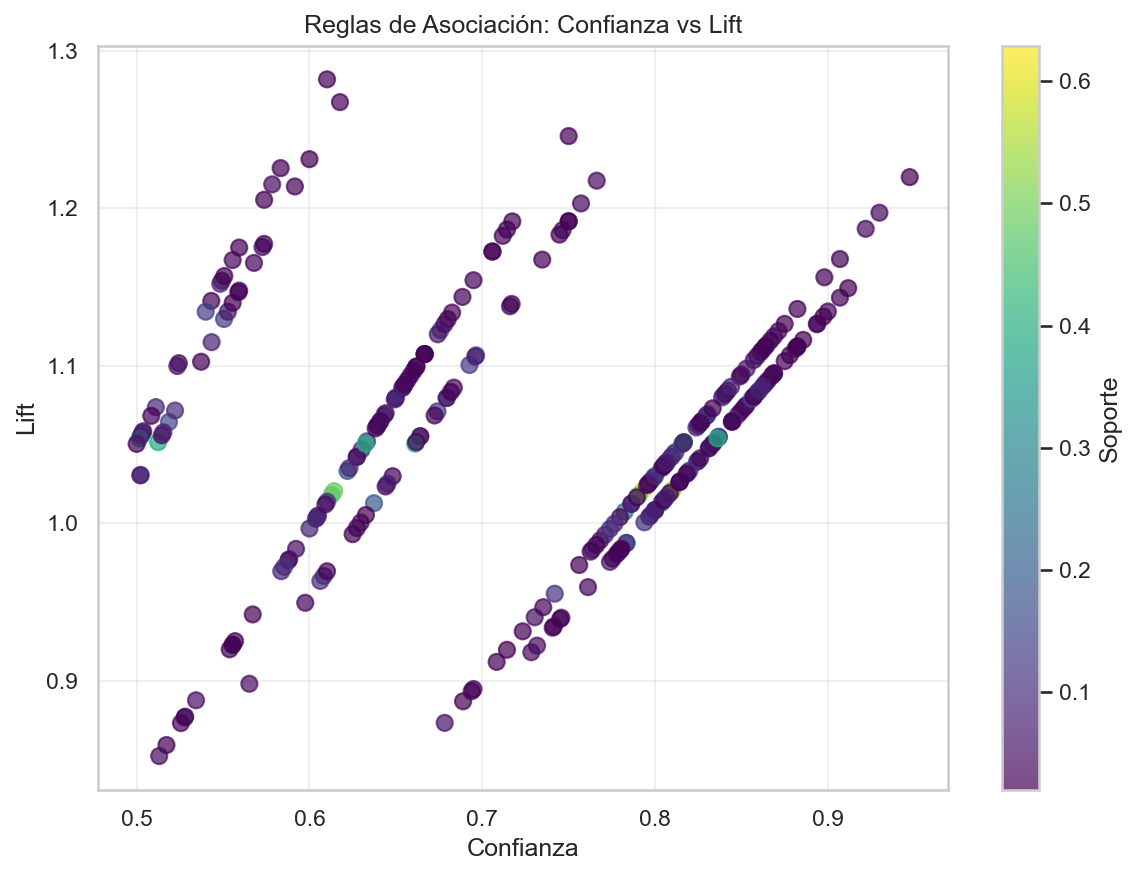

In [74]:
# Reglas de asociación (confianza ≥ 50%)
ra.generar_reglas(metric='confidence', min_threshold=0.50)

print("Reglas con consecuente 'SNACKS Y PREMIOS':")
r_snacks = ra.filtrar_reglas_por_consecuente('SNACKS Y PREMIOS')
if not r_snacks.empty:
    print(r_snacks[['antecedents','consequents','support','confidence','lift']].head(8).to_string(index=False))

ra.grafico_reglas(figsize=(8, 6), show=True);

=== Recomendaciones por ítem en el carrito ===

Recomendaciones para {'SECOS'}:
  → HUMEDOS  (conf=0.912, lift=1.149)
  → HUMEDOS  (conf=0.907, lift=1.143)
  → HUMEDOS  (conf=0.900, lift=1.134)
  → HUMEDOS  (conf=0.897, lift=1.131)
  → HUMEDOS  (conf=0.894, lift=1.127)

Recomendaciones para {'JUGUETES'}:
  → HUMEDOS  (conf=0.907, lift=1.143)
  → HUMEDOS  (conf=0.868, lift=1.094)
  → SECOS  (conf=0.867, lift=1.116)
  → HUMEDOS  (conf=0.865, lift=1.091)
  → HUMEDOS  (conf=0.860, lift=1.084)

Recomendaciones para {'HUMEDOS'}:
  → SECOS  (conf=0.947, lift=1.220)
  → SECOS  (conf=0.930, lift=1.197)
  → SECOS  (conf=0.922, lift=1.187)
  → SECOS  (conf=0.907, lift=1.168)
  → SECOS  (conf=0.882, lift=1.136)


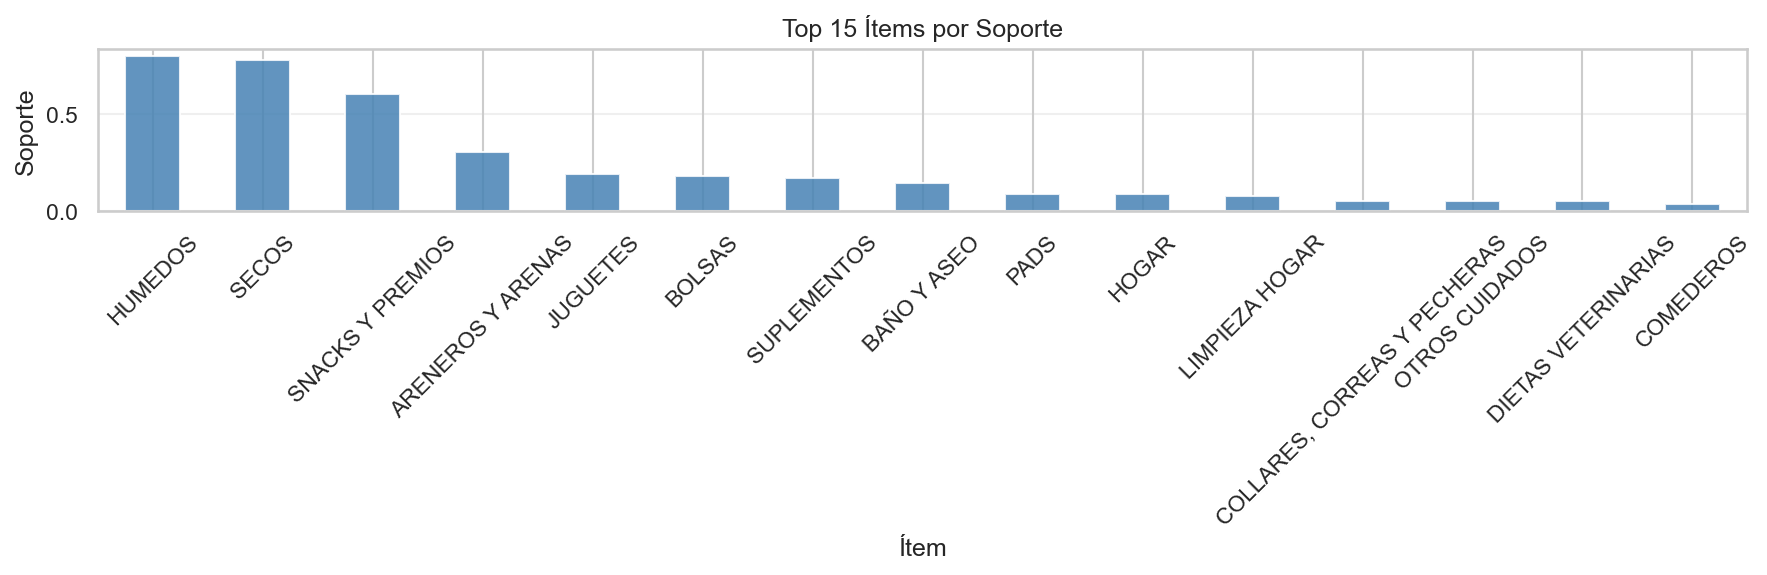


RESUMEN - REGLAS DE ASOCIACION
Transacciones : 1500
Ítems únicos  : 27
Soporte medio : 0.1414

Itemsets frecuentes: 168
Top 5 por soporte:
                   itemsets  support
                  (HUMEDOS) 0.793333
                    (SECOS) 0.776667
           (SECOS, HUMEDOS) 0.629333
         (SNACKS Y PREMIOS) 0.602000
(SNACKS Y PREMIOS, HUMEDOS) 0.487333

Reglas generadas : 294
Confianza media  : 0.722
Lift medio       : 1.059


In [75]:
# Sistema de recomendación de subcategorías
print('=== Recomendaciones por ítem en el carrito ===')
ra.recomendar('SECOS',    top_n=5)
ra.recomendar('JUGUETES', top_n=5)
ra.recomendar('HUMEDOS',  top_n=5)

ra.grafico_top_items(n=15, figsize=(12, 4), show=True)
ra.resumen()

---
## 3. Redes Neuronales — Clasificación del Rango de Precio

Con los atributos del catálogo (mascota, tipo, subcategoría, edad, tamaño) construimos **3 tipos de redes neuronales** con `MLPClassifier` de scikit-learn para predecir el rango de precio del producto: **BAJO**, **MEDIO** o **ALTO**.

Los atributos categóricos se codifican con One-Hot Encoding (OHE), generando el vector de features de entrada.

| Tipo | Activación | Solver | Diferencia |
|------|-----------|--------|------------|
| 1 | `relu` | `adam` | Activación rectificada, optimizador adaptativo |
| 2 | `tanh` | `adam` | Activación tangente hiperbólica, mismo optimizador |
| 3 | `tanh` | `lbfgs` | Mismo activación, optimizador cuasi-Newton |

In [76]:
FEATURES = ['Mascota', 'Tipo', 'Subcategoria', 'Edad', 'Tamano']
TARGET   = 'RangoPrecio'

df_nn = df[FEATURES + [TARGET]].dropna().copy()
df_nn = df_nn[df_nn[TARGET].isin(['BAJO', 'MEDIO', 'ALTO'])]

X = pd.get_dummies(df_nn[FEATURES]).astype(float)
y = df_nn[TARGET]

print(f'Features OHE: {X.shape[1]} columnas')
print(f'Muestras    : {len(y)}')
print(f'\nDistribución del target:')
for clase, cnt in y.value_counts().items():
    print(f'  {clase:<8} {cnt:>4} ({cnt/len(y):.1%})')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Features OHE: 42 columnas
Muestras    : 1103

Distribución del target:
  MEDIO     532 (48.2%)
  BAJO      388 (35.2%)
  ALTO      183 (16.6%)

Train: 827 | Test: 276


In [77]:
rn = pm.RedesNeuronales(X_train, X_test, y_train, y_test, tarea='clasificacion')
print(f'Clases: {list(rn._encoder.classes_)}')

RedesNeuronales — tarea: clasificacion
Train: (827, 42) | Test: (276, 42)
Clases: ['ALTO', 'BAJO', 'MEDIO']


### 3.1 Tipos 1–3: MLPClassifier (scikit-learn)

In [78]:
# Tipo 1: relu + adam
print('─── Tipo 1: relu + adam ───')
modelo1, met1 = rn.red_mlp_sklearn(capas=(128,64,32), activation='relu', solver='adam', max_iter=500)

─── Tipo 1: relu + adam ───

Tipo 1: MLP sklearn  (capas=(128, 64, 32), activation=relu, solver=adam)

  MLP sklearn (relu+adam)
  Matriz de Confusión:
[[  8   1  37]
 [  1  66  30]
 [  4  10 119]]
  Precisión Global:
0.6992753623188406
  Error Global:
0.3007246376811594


In [79]:
# Tipo 2: tanh + adam
print('─── Tipo 2: tanh + adam ───')
modelo2, met2 = rn.red_mlp_sklearn(capas=(128,64,32), activation='tanh', solver='adam', max_iter=500)

─── Tipo 2: tanh + adam ───

Tipo 1: MLP sklearn  (capas=(128, 64, 32), activation=tanh, solver=adam)

  MLP sklearn (tanh+adam)
  Matriz de Confusión:
[[ 13   2  31]
 [  2  79  16]
 [  6  22 105]]
  Precisión Global:
0.7137681159420289
  Error Global:
0.28623188405797106


In [80]:
# Tipo 3: tanh + lbfgs
print('─── Tipo 3: tanh + lbfgs ───')
modelo3, met3 = rn.red_mlp_sklearn(capas=(128,64,32), activation='tanh', solver='lbfgs', max_iter=500)

─── Tipo 3: tanh + lbfgs ───

Tipo 1: MLP sklearn  (capas=(128, 64, 32), activation=tanh, solver=lbfgs)

  MLP sklearn (tanh+lbfgs)
  Matriz de Confusión:
[[29  1 16]
 [ 2 62 33]
 [32  6 95]]
  Precisión Global:
0.6739130434782609
  Error Global:
0.32608695652173914


### 3.2 Benchmark Comparativo

      Modelo  Precisión    Error
 relu + adam   0.699275 0.300725
 tanh + adam   0.713768 0.286232
tanh + lbfgs   0.673913 0.326087


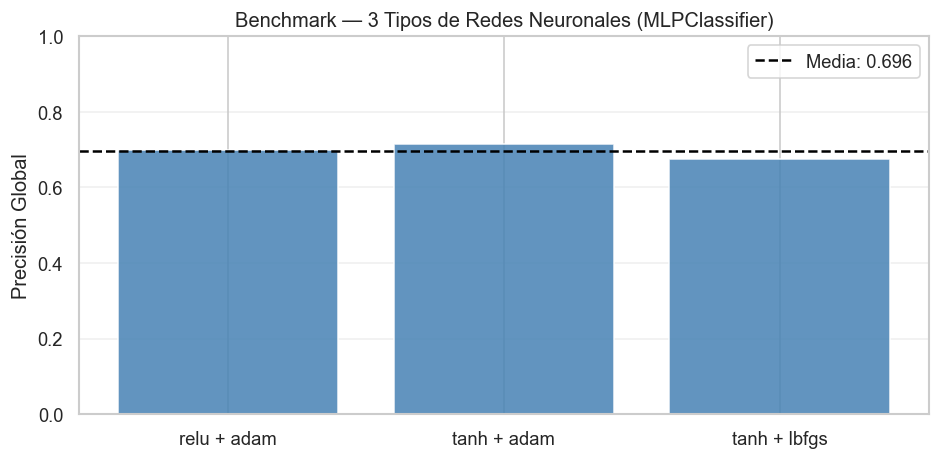

In [81]:
# Benchmark comparativo — 3 tipos MLP sklearn
nombres_bench = ['relu + adam', 'tanh + adam', 'tanh + lbfgs']
mets_bench    = [met1, met2, met3]

filas_bench = []
for nombre, met in zip(nombres_bench, mets_bench):
    if met and 'Precisión Global' in met:
        filas_bench.append({'Modelo': nombre,
                            'Precisión': met['Precisión Global'],
                            'Error': met['Error Global']})

df_bench = pd.DataFrame(filas_bench)
print(df_bench.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_bench['Modelo'], df_bench['Precisión'], color='steelblue', alpha=0.85, edgecolor='white')
ax.axhline(df_bench['Precisión'].mean(), color='black', linestyle='--', lw=1.5,
           label=f"Media: {df_bench['Precisión'].mean():.3f}")
ax.set_title('Benchmark — 3 Tipos de Redes Neuronales (MLPClassifier)')
ax.set_ylabel('Precisión Global')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [82]:
# Mejor modelo: matriz de confusión y precisión por clase
resultados = []
for nombre, met in [('relu+adam', met1), ('tanh+adam', met2), ('tanh+lbfgs', met3)]:
    if met and 'Precisión Global' in met:
        resultados.append((nombre, met['Precisión Global'], met))

if resultados:
    resultados.sort(key=lambda x: x[1], reverse=True)
    mejor, pg, m = resultados[0]
    print(f'Mejor modelo    : {mejor}')
    print(f'Precisión global: {pg:.4f}')
    print(f'\nMatriz de Confusión:')
    print(m['Matriz de Confusión'])
    print(f'\nPrecisión por clase:')
    mc = m['Matriz de Confusión']
    for i, clase in enumerate(rn._encoder.classes_):
        p = mc[i,i] / mc[i].sum() if mc[i].sum() > 0 else 0
        print(f'  {clase:<8}: {p:.1%}')

Mejor modelo    : tanh+adam
Precisión global: 0.7138

Matriz de Confusión:
[[ 13   2  31]
 [  2  79  16]
 [  6  22 105]]

Precisión por clase:
  ALTO    : 28.3%
  BAJO    : 81.4%
  MEDIO   : 78.9%


---
## 4. Conclusiones

**Sitio de escenario**: `https://zoomies.cr/` — Tienda de mascotas en línea, Costa Rica.

### Web Mining
- API Algolia expone **1,137 productos** reales con precio, marca, categoría y ventas del mes. `re.findall()` extrae gramaje y tipo de presentación de los nombres. Técnica principal aplicada. 

### Reglas de Asociación
- Se generaron **294 reglas** con confianza entre 50% y 94.7% a partir de 1,500 órdenes simuladas.
- Las subcategorías más compradas juntas son **HUMEDOS + SECOS** (soporte 63%) — comportamiento coherente con dueños que combinan dietas húmeda y seca.
- Regla más fuerte: `SECOS → HUMEDOS` (confianza 0.947, lift 1.220).
- El sistema de recomendación identifica correctamente productos complementarios: quien compra JUGUETES también tiende a comprar HUMEDOS y SECOS.

### Redes Neuronales
- Se entrenaron 3 variantes de `MLPClassifier` para predecir el rango de precio (BAJO / MEDIO / ALTO).
- El mejor modelo fue **tanh + adam** con **71.4% de precisión global**.
- Las clases BAJO y MEDIO se predicen con alta precisión (81% y 79% respectivamente).
- La clase ALTO tiene solo 28.3% de acierto — esperado, ya que representa apenas el 16.6% de los productos y el modelo tiene pocos ejemplos para aprender ese patrón.
- El solver `lbfgs` (67.4%) fue el menos preciso en este dataset, posiblemente por sensibilidad a la escala de los datos OHE.